In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from scipy.signal import find_peaks
from multiprocessing import Pool
from functools import partial
sys.path.insert(0, '/home/jbreda/PROseq/scripts/Phase_to_LabColor')
from phase_to_labcolor import phase_to_labcolor as p2lc
import astropy.stats.circstats as circstats

# Get data

In [8]:
genome = 'GRCm38'

# get gene gtf
infile_gtf = f"../resources/genome/{genome}/gene_annotation.gtf"
gene_gtf = pd.read_csv(infile_gtf, sep='\t', comment='#', header=None)
gene_gtf.columns = ['chrom','source','feature','start','end','score','strand','frame','attributes']
# parse the gtf's 9 th column (attributes sep by ;)
attributes = ['gene_id','gene_type','gene_name','transcript_id','transcript_type','transcript_name']
for att in attributes:
    gene_gtf[att] = gene_gtf['attributes'].str.extract(rf'{att} "(.*?)";')
# remove attributes column
gene_gtf = gene_gtf.drop(columns=['attributes'])

# get extended kalman filter data
bin_size = 1000
infile_kalman = f"../results/{genome}/kalman/extended_kalman_on_chromosomes_bin{bin_size}bp.csv"
kalman = pd.read_csv(infile_kalman, sep='\t')

# get bin phase amplitude
bin_phase_amp = {}
for bs in [1000,10000]:
    
    bin_phase_amp[bs] = {}

    infile_bin_fw = f"../results/{genome}/phase_amp/bin_phase_amp_forward_{bs}bp.csv"
    infile_bin_rv = f"../results/{genome}/phase_amp/bin_phase_amp_reverse_{bs}bp.csv"
    bin_phase_amp[bs]['+'] = pd.read_csv(infile_bin_fw, sep='\t')
    bin_phase_amp[bs]['-'] = pd.read_csv(infile_bin_rv, sep='\t')

# get gene phase amplitude
infile_gene = f"../results/GRCm38/phase_amp/gene_phase_amp.csv"
gene_phase_amp = pd.read_csv(infile_gene, sep='\t')
gene_phase_amp.set_index('gene_id',inplace=True)

# TAD
infile = '../resources/TAD/TADMap_scaffold_mm10.bed'
tad = pd.read_csv(infile, sep=' ', header=None)
tad.columns = ['chrom','start','end']


In [25]:
tad

chrom = 'chr4'
start = 49_350_000
end = 49_650_000


tad_region = tad[(tad['chrom'] == chrom) & (tad['end'] > start) & (tad['start'] < end)]

In [26]:
tad_region

,chrom,start,end
2044,chr4,48700000,49650000


In [27]:
def plot_region(kalman,gene_gtf,bin_phase_amp,bin_size,region_coords,fig_folder):

    chrom, start, end = region_coords.split(':')
    start = int(start)
    end = int(end)

    # k mean
    ω = 2*np.pi/24 #  [rad/h] 
    v_mean = 34 # [bp/s]
    v_mean *= 1e-3 # [kb/s]
    v_mean *= 3600 # [kb/h]
    k_mean = ω/v_mean # [rad/kb]

    # plot : 2 strands * (k, phase, LL, genes)
    N_tracks = 4
    fig, axes = plt.subplots(nrows=2*N_tracks, ncols=1, figsize=(12, 8))
    fplus = N_tracks-1
    fminus = N_tracks
    for strand in ['+','-']:

        region_data = kalman[(kalman['chr'] == chrom) & (kalman['start'] >= start) & (kalman['end'] <= end) & (kalman['strand'] == strand)]
        region_gtf = gene_gtf[(gene_gtf['chrom'] == chrom) & (gene_gtf['start'] >= start) & (gene_gtf['end'] <= end) & (gene_gtf['strand'] == strand)]

        x = region_data['start'].values+bin_size/2

        # elongation rate
        k = region_data['k'].values

        # phase
        phi = region_data['phi'].values
        A = region_data['amp'].values
        σ_A = region_data['var_amp'].values
        col = p2lc(phi,amp=A,th_amp=0.1)

        # k effective dphi/dx
        k_eff = (phi[1:] - phi[:-1])/(x[1:] - x[:-1]) # [rad/bp]
        k_eff *= 1e3 # [rad/kb]

        # bin phase at 10000 kb binning
        idx_bin = (bin_phase_amp[10000][strand]['chr'] == chrom) & (bin_phase_amp[10000][strand]['start'] >= start) & (bin_phase_amp[10000][strand]['end'] <= end)
        x_bin =   bin_phase_amp[10000][strand][idx_bin]['start'].values + bin_size/2
        phi_bin = bin_phase_amp[10000][strand][idx_bin]['phase'].values        
        amp_bin = bin_phase_amp[10000][strand][idx_bin]['amplitude'].values
        col_bin = p2lc(phi_bin,amp=amp_bin,th_amp=0.1)

        # LL
        LL = region_data['LL'].values

        # get genes in region
        genes = region_gtf[(region_gtf['feature'] == 'gene')]['gene_id'].values

        # first track: genes
        if strand == '+':
            ax = axes[fplus]
        elif strand == '-':
            ax = axes[fminus]
        
        y = 0
        for gene in genes:

            my_gene = region_gtf[(region_gtf['gene_id'] == gene) & (region_gtf['feature'] == 'gene')]
            if len(my_gene) > 0:
                my_gene = my_gene.iloc[0]


            if my_gene.gene_id in gene_phase_amp.index:
                gene_phi = np.array([ gene_phase_amp.at[my_gene.gene_id,'phase'] ])
                gene_amp = np.array([ gene_phase_amp.at[my_gene.gene_id,'amplitude'] ])
                gene_color = p2lc(gene_phi,gene_amp,th_amp=0.1)
            else:
                gene_color = 'black'

            ax.hlines(y,my_gene.start,my_gene.end, color=gene_color, linewidth=1)
            ax.text(my_gene.start, y, my_gene.gene_name+' ', fontsize=6,ha='right', va='center')

            for exon in region_gtf[(region_gtf['gene_id'] == gene) & (region_gtf['feature'] == 'exon')].itertuples(index=False):
                ax.hlines(y,exon.start,exon.end, color=gene_color, linewidth=3)
            
            y = (y+1)%6
        ax.set_xlim([start,end])
        for tick in ax.get_xticks():
            ax.axvline(tick, color='k', alpha=0.2, linewidth=0.5)
        ax.set_ylabel('genes')
        ax.axis('off')

        # 2nd track: Amp and phase
        if strand == '+':
            fplus -=1
            ax = axes[fplus]
        elif strand == '-':
            fminus +=1
            ax = axes[fminus]
        
        ax.scatter(x, A, c=col, s=2)
        ax.scatter(x_bin, -.5*np.ones(len(x_bin)), c=col_bin, s=20)
        ax.set_xticklabels([])
        ax.set_xlim([start,end])
        ax.set_ylabel(r'$A$')
        ax.grid()

        # 3rd track: LL
        if strand == '+':
            fplus -=1
            ax = axes[fplus]
        elif strand == '-':
            fminus +=1
            ax = axes[fminus]

        ax.plot(x, LL, 'k')
        ax.set_xticklabels([])
        ax.set_xlim([start,end])
        ax.set_ylabel('LL')
        ax.grid()

        # 45th track: k(x)
        if strand == '+':
            fplus -=1
            ax = axes[fplus]
        elif strand == '-':
            fminus +=1
            ax = axes[fminus]

        ax.hlines(k_mean, start, end, color='r', linestyle='--')
        ax.plot(x, k, 'k')
        #ax.plot(x[:-1]+(bin_size*1e-3)/2, k_eff)
        #ax.set_ylim([-5*k_mean,5*k_mean])
        ax.set_xticklabels([])
        ax.set_xlim([start,end])
        ax.set_ylabel('k [rad/kb]')
        ax.grid()
    
    ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])
    ax.set_xlabel(f'position on {chrom} [Mb]')

    fig.tight_layout()
    fig.savefig(f"{fig_folder}/{region_coords.replace(':','_')}.pdf")




def plot_region_small(kalman,gene_gtf,bin_phase_amp,tad,bin_size,region_coords,fig_folder):

    chrom, start, end = region_coords.split(':')
    start = int(start)
    end = int(end)

    # plot : 2 strands * (kalman, bin, genes) + tad
    N_tracks = 3
    fig, axes = plt.subplots(nrows=2*N_tracks+1, ncols=1, figsize=(10, 5), gridspec_kw={'hspace': 0, 'height_ratios': [1, 1, 1, 0.1, 1, 1, 1]})

    # plot tads
    region_tad = tad[(tad['chrom'] == chrom) & (tad['end'] > start) & (tad['start'] < end)]
    ax = axes[N_tracks]
    x = 0
    for tad in region_tad.itertuples(index=False):
        ax.hlines(x, tad.start, tad.end, color='k', linewidth=1)
        x = x+1%2
    if region_tad.shape[0] > 0:
        ax.set_ylim([-0.1,1.1])
    else:
        ax.set_ylim([-0.1,0.1])
    ax.set_xlim([start,end])
    ax.set_xticklabels([])
    ax.set_ylabel('TADs')
    ax.axis('off')

    fplus = N_tracks-1
    fminus = N_tracks+1
    for strand in ['+','-']:


        region_data = kalman[(kalman['chr'] == chrom) & (kalman['start'] >= start) & (kalman['end'] <= end) & (kalman['strand'] == strand)]
        region_gtf = gene_gtf[(gene_gtf['chrom'] == chrom) & (gene_gtf['start'] >= start) & (gene_gtf['end'] <= end) & (gene_gtf['strand'] == strand)]

        x_kalman = region_data['start'].values+bin_size/2

        # phase kalman
        phi_kalman = region_data['phi'].values
        A_kalman = region_data['amp'].values
        σ_A_kalman = region_data['var_amp'].values
        col_kalman = p2lc(phi_kalman,amp=A_kalman,th_amp=0.1)

        # bin phase at 10000 kb binning
        bs = 1000
        idx_bin = (bin_phase_amp[bs][strand]['chr'] == chrom) & (bin_phase_amp[bs][strand]['start'] >= start) & (bin_phase_amp[bs][strand]['end'] <= end)
        x_bin =   bin_phase_amp[bs][strand][idx_bin]['start'].values + bin_size/2
        phi_bin = bin_phase_amp[bs][strand][idx_bin]['phase'].values        
        A_bin = bin_phase_amp[bs][strand][idx_bin]['amplitude'].values
        col_bin = p2lc(phi_bin,amp=A_bin,th_amp=0.1)

        # get genes in region
        genes = region_gtf[(region_gtf['feature'] == 'gene')]['gene_id'].values

        # 1st track: genes
        if strand == '+':
            ax = axes[fplus]
        elif strand == '-':
            ax = axes[fminus]
        
        y = 0
        for gene in genes:

            my_gene = region_gtf[(region_gtf['gene_id'] == gene) & (region_gtf['feature'] == 'gene')]
            if len(my_gene) > 0:
                my_gene = my_gene.iloc[0]

            if my_gene.gene_id in gene_phase_amp.index:
                gene_phi = np.array([ gene_phase_amp.at[my_gene.gene_id,'phase'] ])
                gene_amp = np.array([ gene_phase_amp.at[my_gene.gene_id,'amplitude'] ])
                gene_color = p2lc(gene_phi,gene_amp,th_amp=0.1)
            else:
                gene_color = 'black'
            
            # draw gene
            ax.hlines(y,my_gene.start,my_gene.end, color=gene_color, linewidth=1)
            # gene name
            ax.text(my_gene.start, y, my_gene.gene_name+' ', fontsize=6,ha='right', va='center')
            # draw exons
            for exon in region_gtf[(region_gtf['gene_id'] == gene) & (region_gtf['feature'] == 'exon')].itertuples(index=False):
                ax.hlines(y,exon.start,exon.end, color=gene_color, linewidth=3)
            # draw promoter
            h = 0.5
            l = 1.5*bin_size
            if my_gene.strand == '+':
                prom = {'x':[my_gene.start,my_gene.start,my_gene.start+l], 'y':[y,y+h,y+h],'m':'>'}
            if my_gene.strand == '-':
                prom = {'x':[my_gene.end,my_gene.end,my_gene.end-l], 'y':[y,y+h,y+h],'m':'<'}
            ax.plot(prom['x'][-1], prom['y'][-1], marker=prom['m'], color=gene_color, markersize=2)
            ax.plot(prom['x'], prom['y'], color=gene_color, linewidth=1)

            
            y = (y+1)%6
        ax.set_xlim([start,end])
        for tick in ax.get_xticks():
            ax.axvline(tick, color='k', alpha=0.2, linewidth=0.5)
        ax.set_ylim([-1,6])
        ax.set_ylabel('genes')
        ax.axis('off')

        # 2nd track: Amp and phase kalman
        if strand == '+':
            fplus -=1
            ax = axes[fplus]
        elif strand == '-':
            fminus +=1
            ax = axes[fminus]
        
        ax.scatter(x_kalman, A_kalman, c=col_kalman, s=2)
        ax.set_xticklabels([])
        ax.set_xlim([start,end])
        ax.set_ylim([0,1.1*A_kalman.max()])
        ax.set_ylabel(r'$A$')
        ax.grid()

        # 3rd track: Amp and phase bin
        if strand == '+':
            fplus -=1
            ax = axes[fplus]
        elif strand == '-':
            fminus +=1
            ax = axes[fminus]

        ax.scatter(x_bin, A_bin, c=col_bin, s=2)
        ax.set_xticklabels([])
        ax.set_xlim([start,end])
        ax.set_ylim([0,1.1*A_bin.max()])
        ax.set_ylabel(r'$A$')
        ax.grid()
    
    ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])
    ax.set_xlabel(f'position on chromosome {chrom.replace("chr","")} [Mb]')

    fig.tight_layout()
    fig.savefig(f"{fig_folder}/{region_coords.replace(':','_')}.pdf")

# Selected regions

/tmp/ipykernel_599901/2211580452.py:270: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])
/tmp/ipykernel_599901/2211580452.py:270: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])
/tmp/ipykernel_599901/2211580452.py:270: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])
/tmp/ipykernel_599901/2211580452.py:270: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])
/tmp/ipykernel_599901/2211580452.py:270: Use

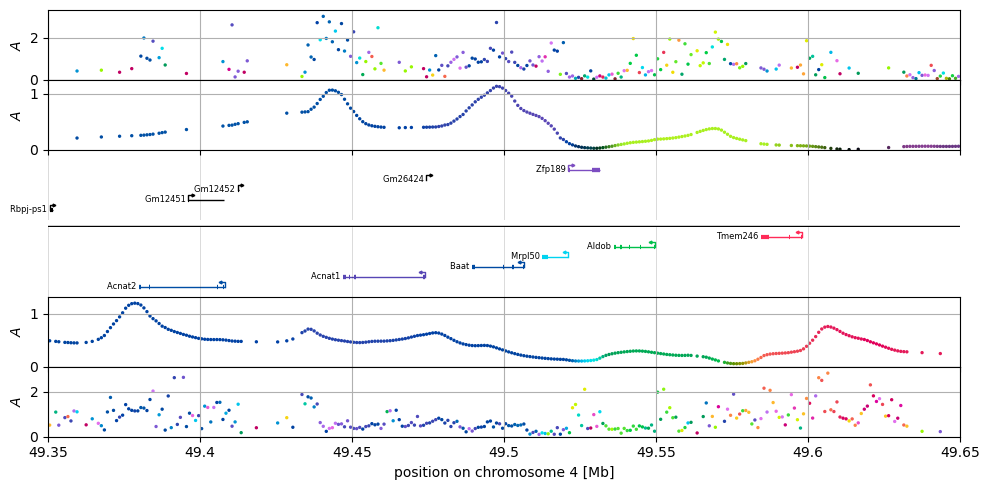

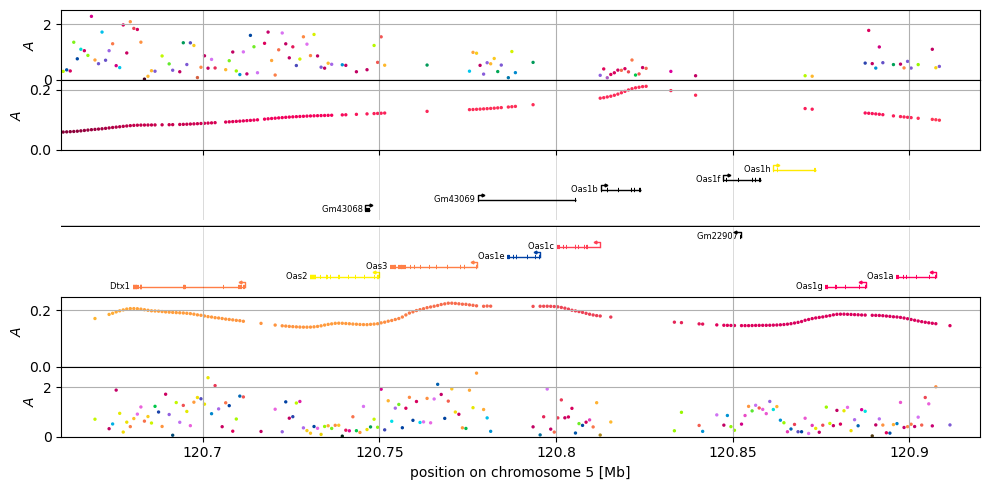

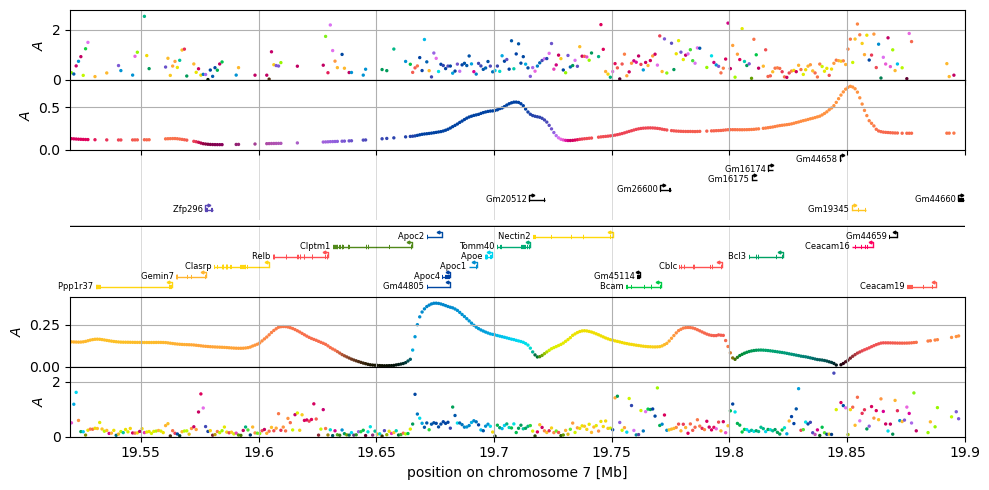

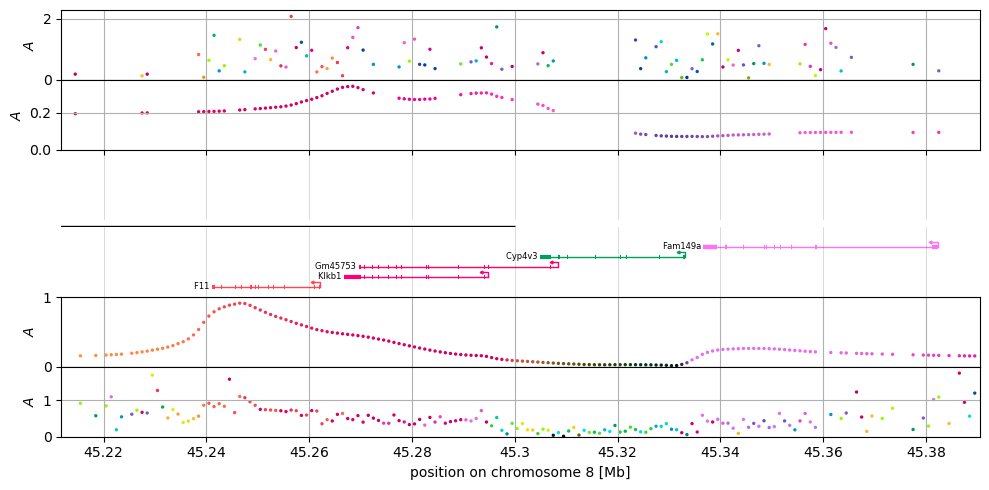

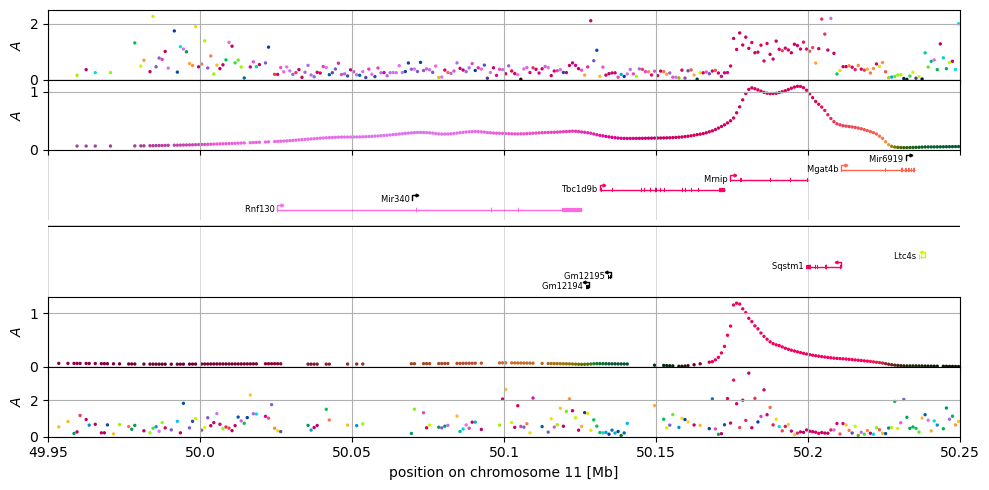

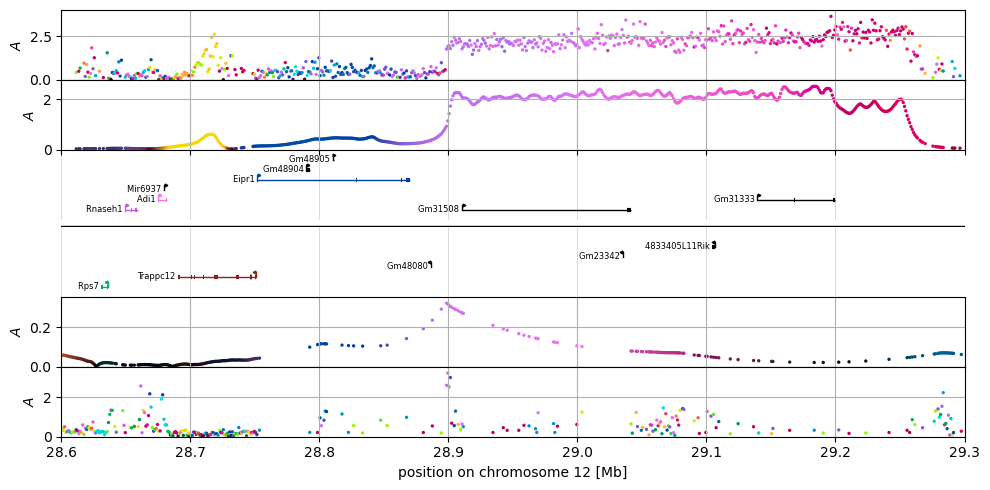

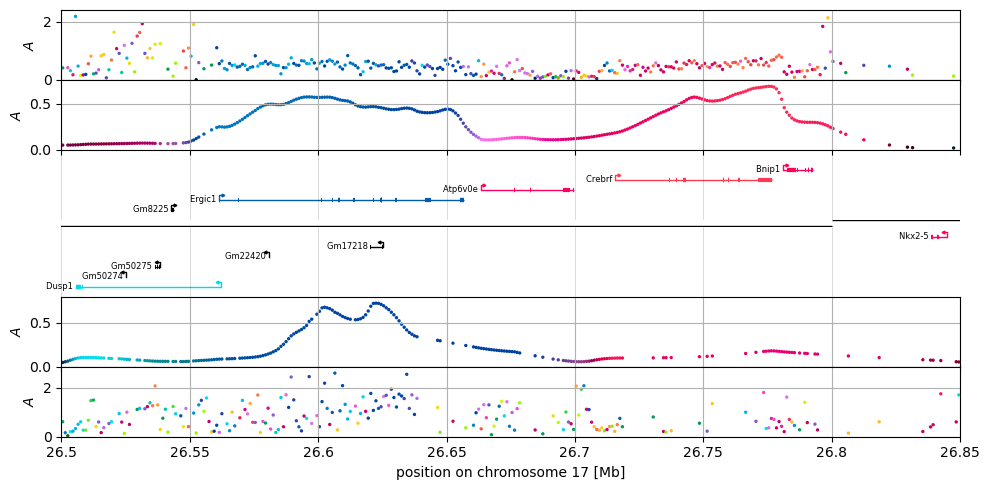

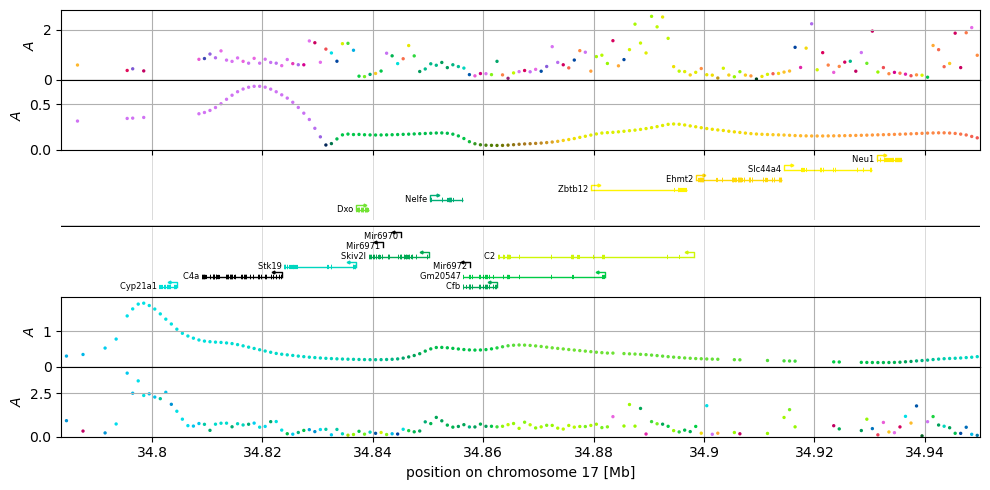

In [28]:
# removed regions :
# 'chr2:11_800_000:13_600_000',
# 'chr2:25_100_000:25_700_000',
# 'chr5:104_888_056:107_620_085',
# 'chr5:121_017_471:126_000_000',
# 'chr5:129_900_000:130_200_000',
# 'chr10:75_000_000:76_750_000',
# 'chr13:55_550_000:55_850_000',
# 'chr17:10_750_000:13_250_000',

Regions = ['chr4:49_350_000:49_650_000',
           'chr5:120_660_000:120_920_000',
           'chr7:19_520_000:19_900_000',
           'chr8:45_211_805:45_390_520',
           'chr11:49_950_000:50_250_000',
           'chr12:28_600_000:29_300_000',
           'chr17:26_500_000:26_850_000',
           'chr17:34_783_585:34_950_000',
           ]

#threads = 84
#with Pool(processes=threads) as pool:
#    pool.map(partial(plot_region,kalman,gene_gtf,bin_phase_amp,bin_size),Regions)
fig_folder = '../results/fig/fig5/selected_regions'

for coord in Regions:
    plot_region_small(kalman,gene_gtf,bin_phase_amp,tad,bin_size,coord,fig_folder)
   


# Get gene clusters with high LL


/tmp/ipykernel_593723/75750456.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gene_gtf_gene.loc[:,'LL_mean'] = 0
/tmp/ipykernel_593723/75750456.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gene_gtf_gene.loc[:,'k_mean'] = 0


/tmp/ipykernel_593723/75750456.py:37: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[nan, nan, 0.00693538963473472, nan, 0.0014072279780570963, nan, nan, 0.0, 0.0, nan, 0.0, 0.008770390100584748, nan, nan, nan, 0.012516205728414508, 0.016906910099407327, 0.0, nan, 0.7129992020120932, 0.2955212593079287, 0.02398955673616678, nan, nan, nan, nan, 0.0, nan, nan, nan, nan, 0.9742347141080657, nan, 0.9600074044625695, 0.9462061424517282, 0.9086935450971424, nan, nan, 0.00549264035142943, nan, 0.0071876150611834035, 0.02138102537535786, nan, 0.8817827787540022, nan, nan, nan, 0.023636706106510415, nan, nan, nan, nan, nan, 0.9129800667954941, 0.9350791472730986, 0.008984571244230716, nan, nan, nan, 0.012739704360533247, nan, nan, nan, nan, nan, nan, 0.0, 0.9716002102786712, nan, 0.9835623365793862, 0.17099567331117452, nan, nan, nan, 0.056459956253221984, nan, 0.02333903986254956, nan, nan, nan, nan, 0.0023386908837212538,

(27429, 16)


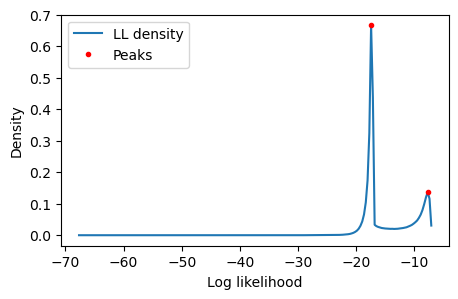

In [4]:
# Plot the log likelihoods distribution
fig, ax = plt.subplots(figsize=(5, 3))
[h,bins] = np.histogram(kalman.LL, bins=200, density=True)
x = 0.5 * (bins[1:] + bins[:-1])  # bin centers
# find local maxima in the histogram
peaks, prop = find_peaks(h, height=0.05)
peaks_x = x[peaks]
peaks_h = prop['peak_heights']
ax.plot(x, h, label='LL density')
ax.plot(peaks_x, peaks_h, 'r.', label='Peaks')
ax.set_xlabel('Log likelihood')
ax.set_ylabel('Density')
ax.legend(loc='upper left')

# clip log likelihoods to the range of the peaks and normalize to [0,1]
kalman['LL_norm'] = np.clip(kalman.LL,peaks_x[0],peaks_x[1])
kalman['LL_norm'] = (kalman['LL_norm'] - peaks_x[0]) / (peaks_x[1] - peaks_x[0])

# get average LL per gene
gene_gtf_gene = gene_gtf.loc[(gene_gtf['feature'] == 'gene'),:]
gene_gtf_gene.loc[:,'LL_mean'] = 0
gene_gtf_gene.loc[:,'k_mean'] = 0
gene_gtf_gene.reset_index(inplace=True, drop=True)

# get average LL and k per gene
def get_mean_LL_k(coord):
    idx = (kalman.chr == coord[0]) & (kalman.start >= coord[1]) & (kalman.end <= coord[2]) & (kalman.strand == coord[3])
    if len(idx) == 0:
        return np.nan
    return kalman.loc[idx,['LL_norm','k']].mean().values

threads = 84
COORD = gene_gtf_gene.loc[:,['chrom','start','end','strand']].values
with Pool(processes=threads) as pool:
    OUT = pool.map(get_mean_LL_k,COORD)

gene_gtf_gene.loc[:,['LL_mean','k_mean']] = OUT

# remove nans
gene_gtf_gene = gene_gtf_gene.loc[~np.isnan(gene_gtf_gene.LL_mean),:]

print(gene_gtf_gene.shape)
gene_gtf_gene.reset_index(inplace=True, drop=True)

# get pair of genes with distance < 20kb and same chr/strand and LL_mean > 0.5 
D = gene_gtf_gene.loc[:,'start'].values[None,:] - gene_gtf_gene.loc[:,'end'].values[:,None]
IDX = (D > 0) & (D < 2e4) & (gene_gtf_gene.loc[:,'chrom'].values[:,None] == gene_gtf_gene.loc[:,'chrom'].values[None,:]) & (gene_gtf_gene.loc[:,'strand'].values[:,None] == gene_gtf_gene.loc[:,'strand'].values[None,:]) & ( (gene_gtf_gene.loc[:,'LL_mean'].values[:,None] > 0.5) * (gene_gtf_gene.loc[:,'LL_mean'].values[None,:] > 0.5) )

[i,j] = np.where(IDX)

# Make gene clusters
gene_clusters = {}
for k, l in zip(i,j):
    if k not in gene_clusters:
        gene_clusters[k] = [l]
    else:
        gene_clusters[k].append(l)

to_del = []
for k in gene_clusters.keys():
    for l in gene_clusters[k]:
        if l in gene_clusters:
            gene_clusters[k].extend(gene_clusters[l])
            to_del.append(l)
    gene_clusters[k] = sorted(gene_clusters[k])

for k in to_del:
    if k in gene_clusters:
        del gene_clusters[k]

for k in gene_clusters.keys():
    gene_clusters[k].append(k)
    gene_clusters[k] = list(set(gene_clusters[k]))

gene_clusters = list(gene_clusters.values())

gene_clusters_table = pd.DataFrame(columns=['chr','start','end','strand','genes','LL_mean','k_mean','n','length_bp'])

for k in range(len(gene_clusters)):
    my_genes = gene_gtf_gene.loc[gene_clusters[k],:]

    gene_clusters_table.loc[k,'chr'] = my_genes.chrom.unique()
    gene_clusters_table.loc[k,'start'] = my_genes.start.min()
    gene_clusters_table.loc[k,'end'] = my_genes.end.max()
    gene_clusters_table.loc[k,'strand'] = my_genes.strand.unique()
    gene_clusters_table.loc[k,'genes'] = my_genes.gene_name.values
    gene_clusters_table.loc[k,'LL_mean'] = my_genes.LL_mean.mean()
    gene_clusters_table.loc[k,'k_mean'] = my_genes.k_mean.mean()
    gene_clusters_table.loc[k,'n'] = len(my_genes)
gene_clusters_table.length_bp = gene_clusters_table.end - gene_clusters_table.start
gene_clusters_table.sort_values('n',ascending=False,inplace=True)

# compute correlation between bin_phase_amp and kalman
def kalman_bin_phase_corr(coord):
    chrom = str(coord[0])
    start = int(coord[1])
    end = int(coord[2])
    strand = str(coord[3])

    idx_kalman = (kalman.chr == chrom) & (kalman.start >= start) & (kalman.end <= end) & (kalman.strand == strand)
    idx_bin = (bin_phase_amp[bin_size][strand]['chr'] == chrom) & (bin_phase_amp[bin_size][strand]['start'] >= start) & (bin_phase_amp[bin_size][strand]['end'] <= end)

    return circstats.circcorrcoef(kalman.loc[idx_kalman,'phi'].values,bin_phase_amp[bin_size][strand].loc[idx_bin,'phase'].values)


COORD = gene_clusters_table[['chr','start','end','strand']].values
threads = 84
with Pool(processes=threads) as pool:
    OUT = pool.map(kalman_bin_phase_corr,COORD)

gene_clusters_table.loc[:,'circ_corr'] = OUT

/tmp/ipykernel_575912/3223403534.py:132: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])
/tmp/ipykernel_575912/3223403534.py:132: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])
/tmp/ipykernel_575912/3223403534.py:132: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])
/tmp/ipykernel_575912/3223403534.py:132: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(round(a*1e-6,2)) for a in ax.get_xticks()])
/tmp/ipykernel_575912/3223403534.py:132: Use

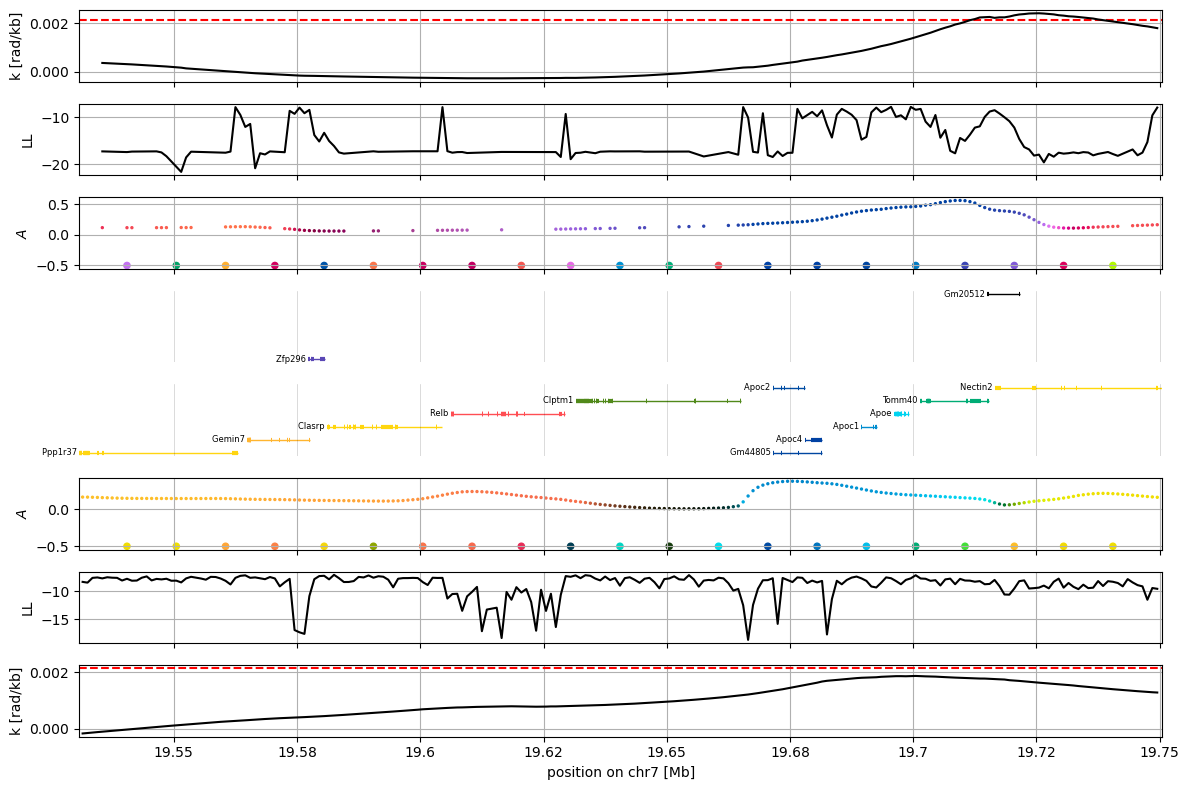

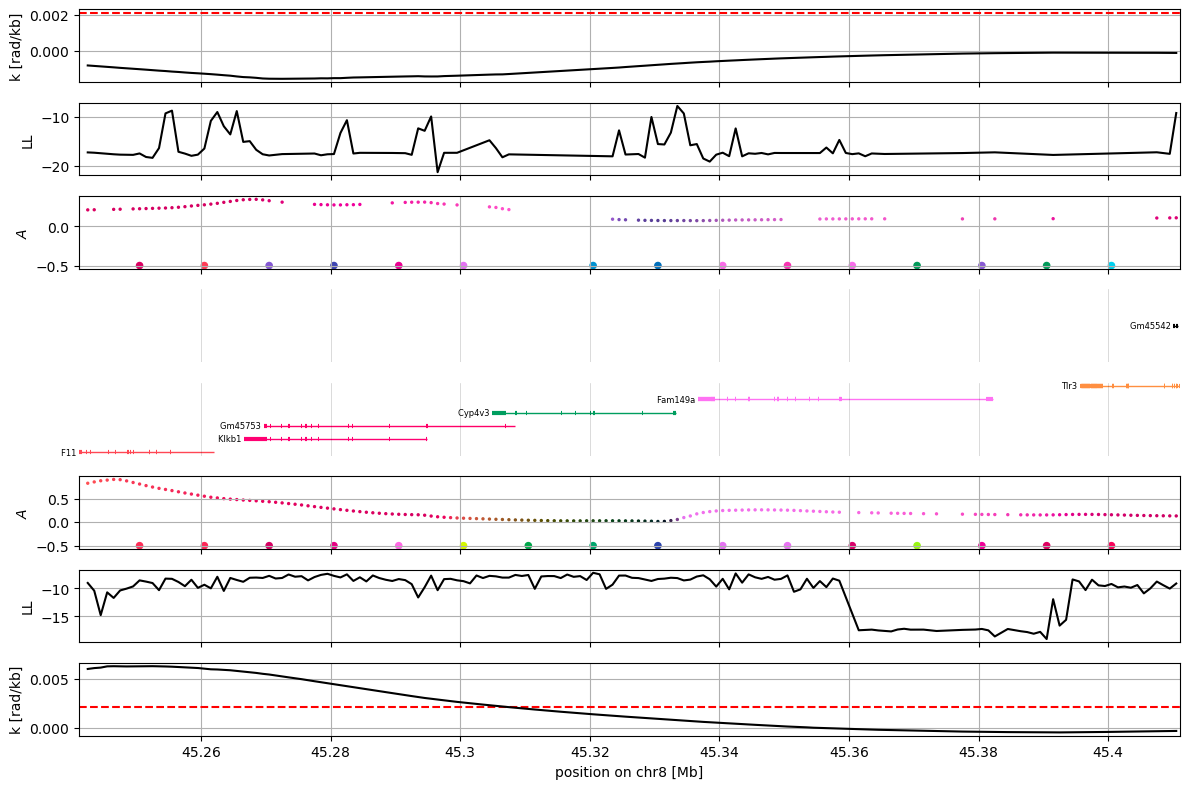

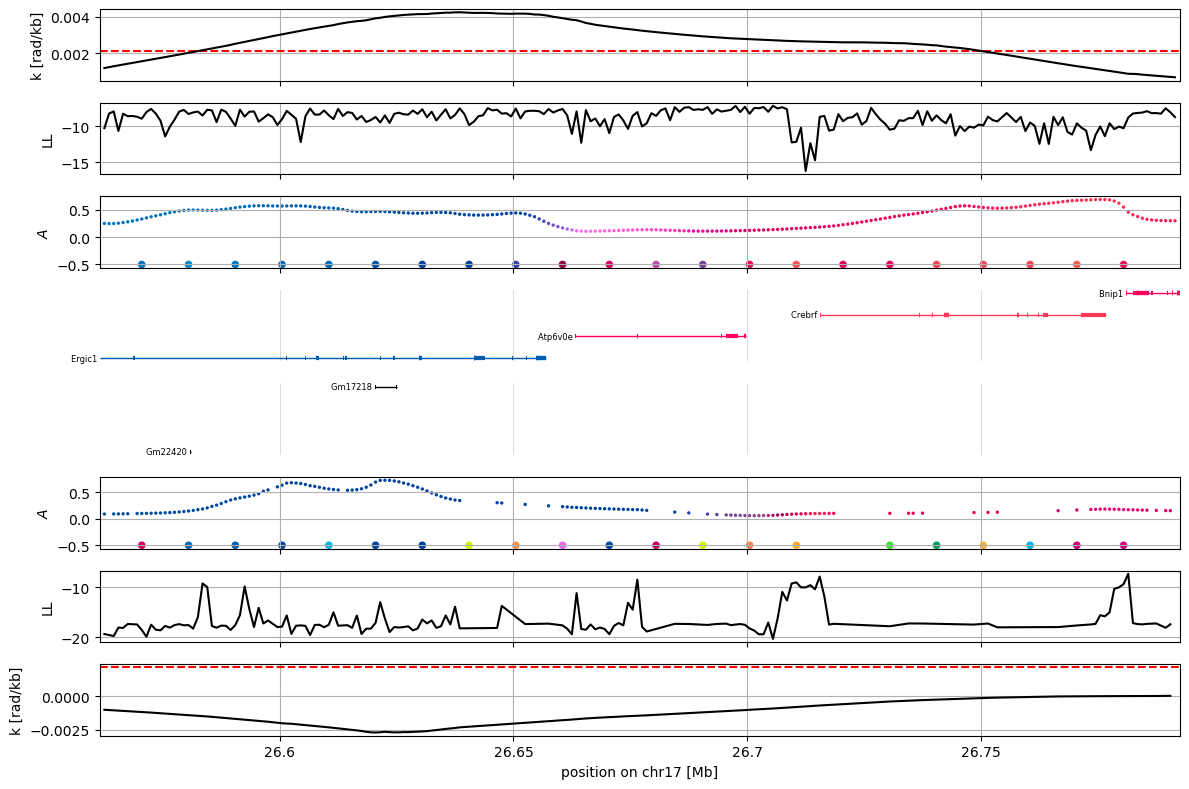

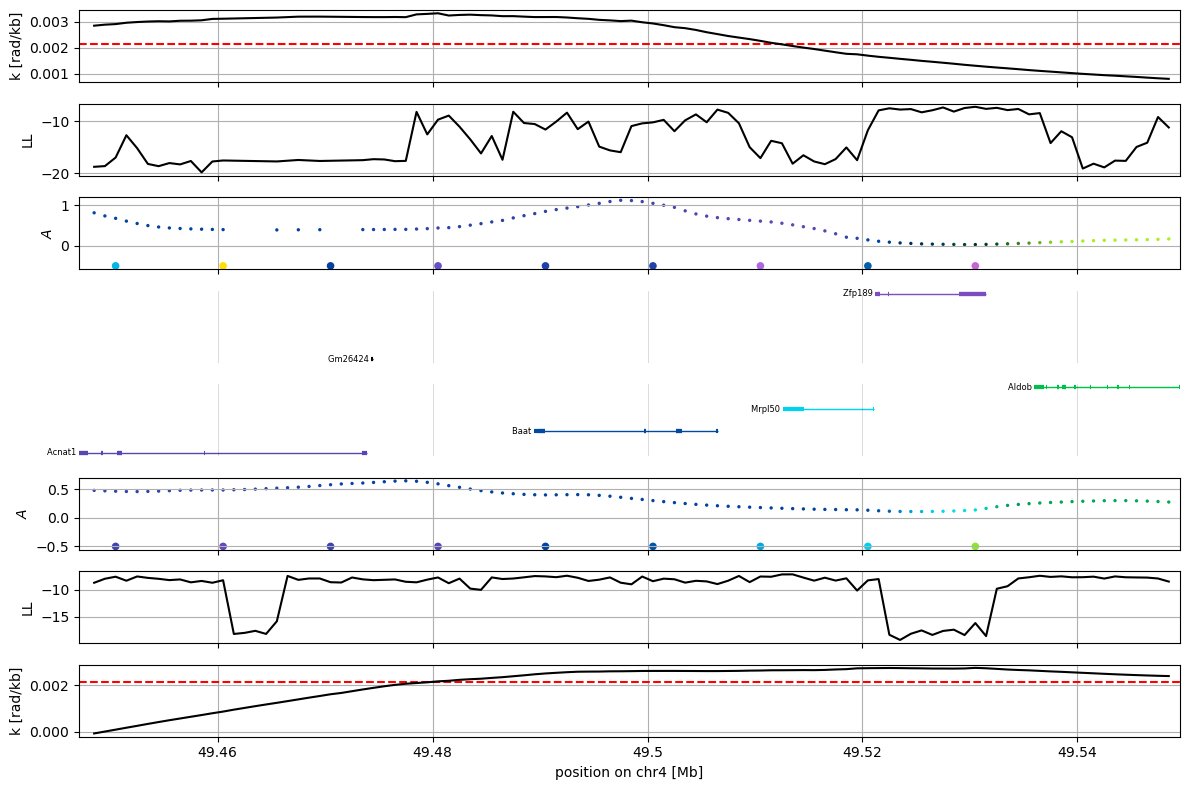

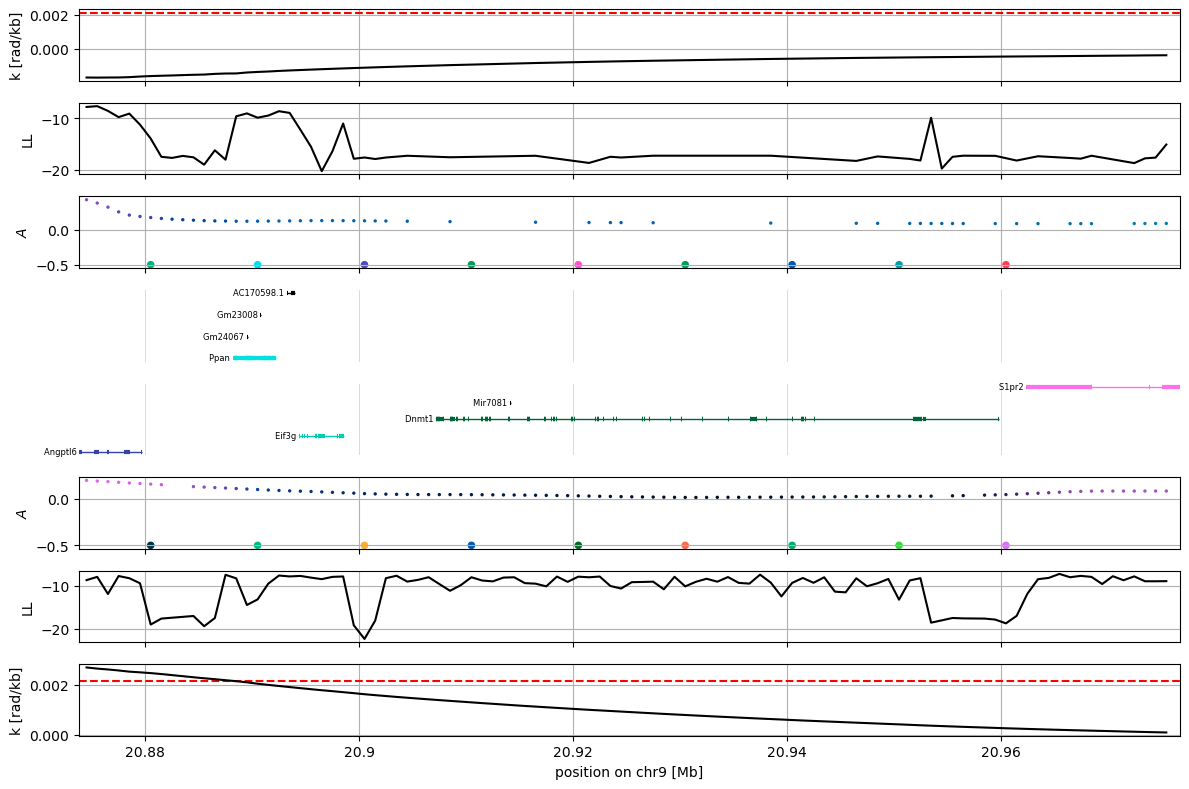

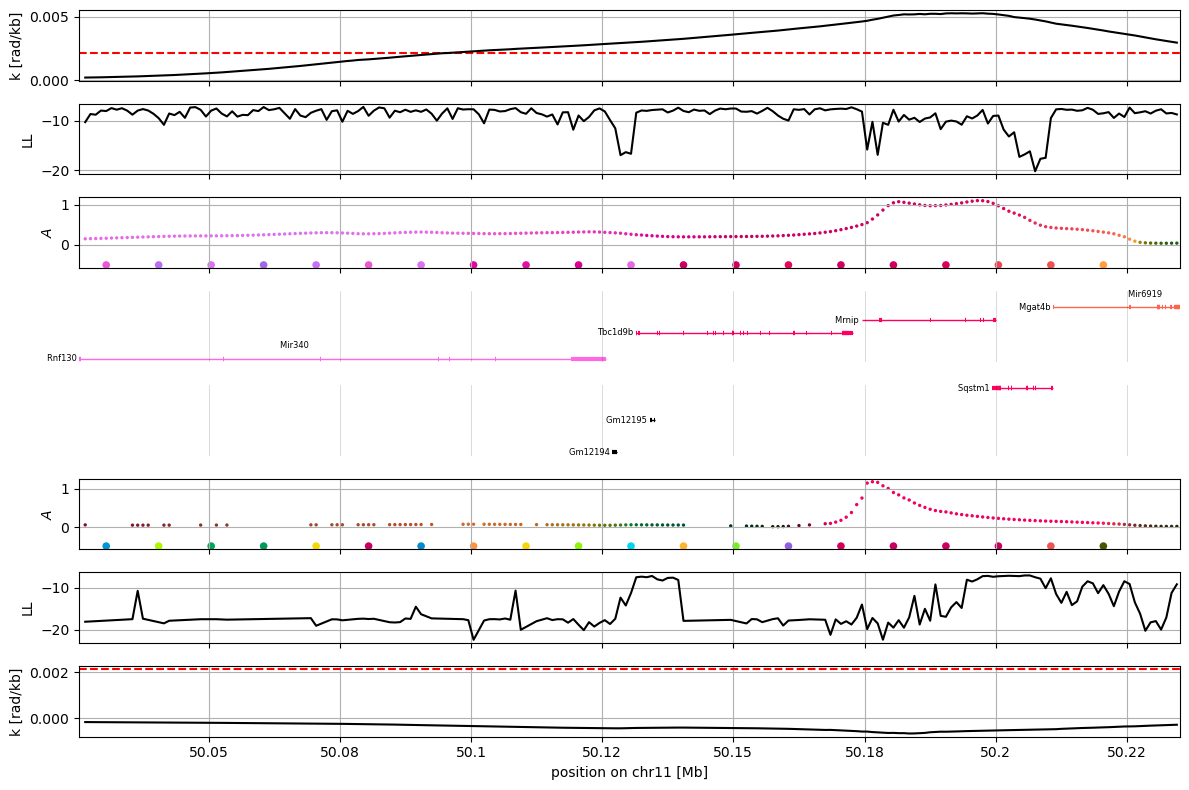

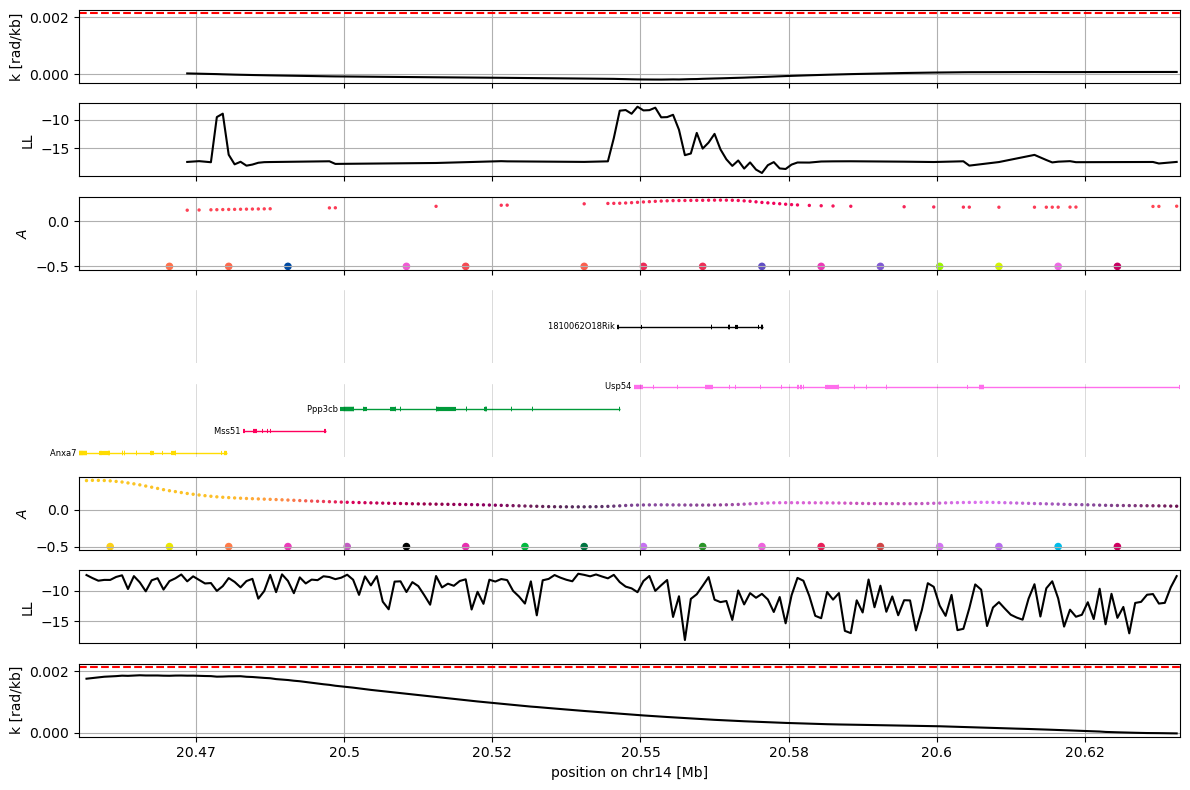

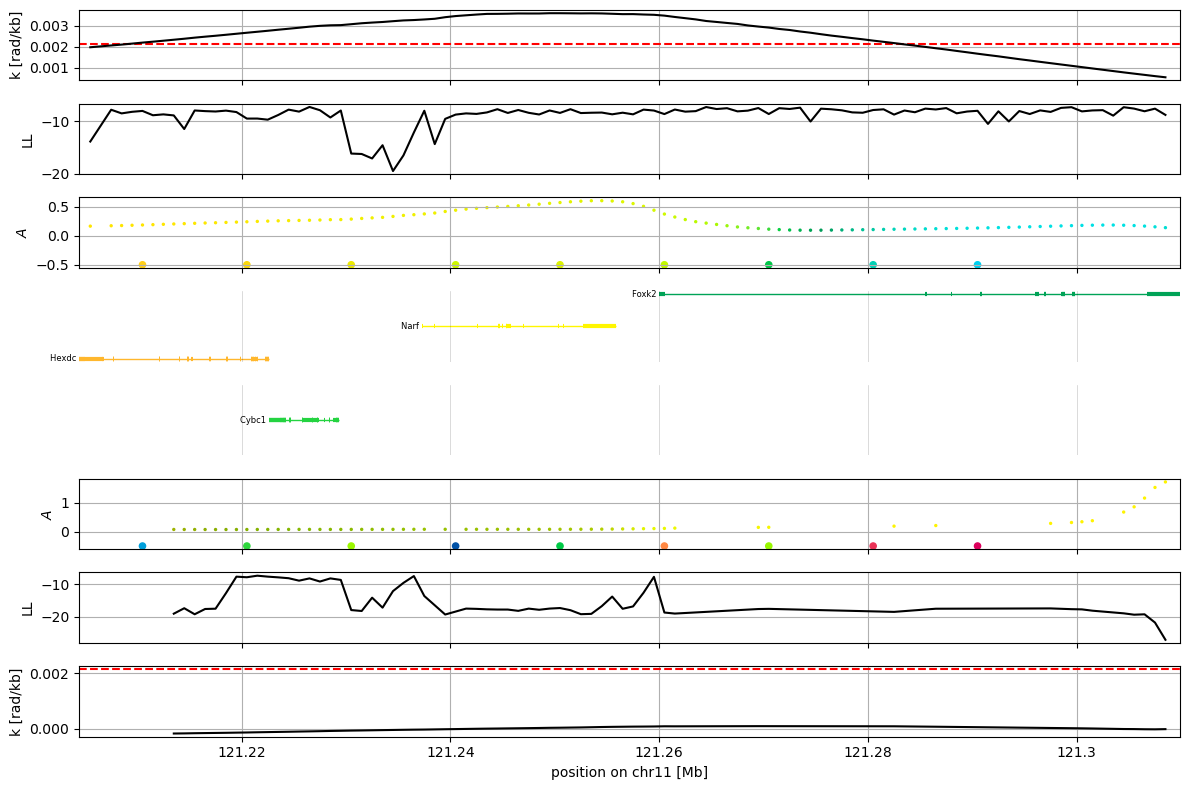

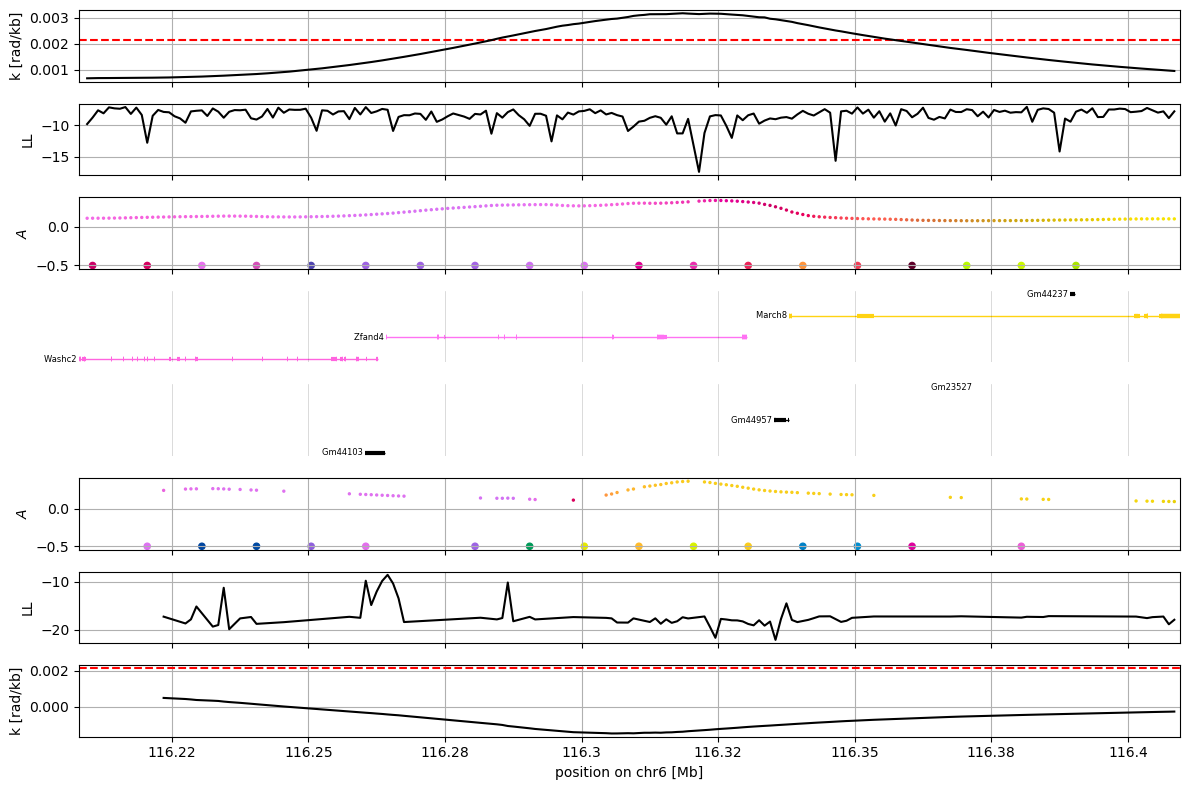

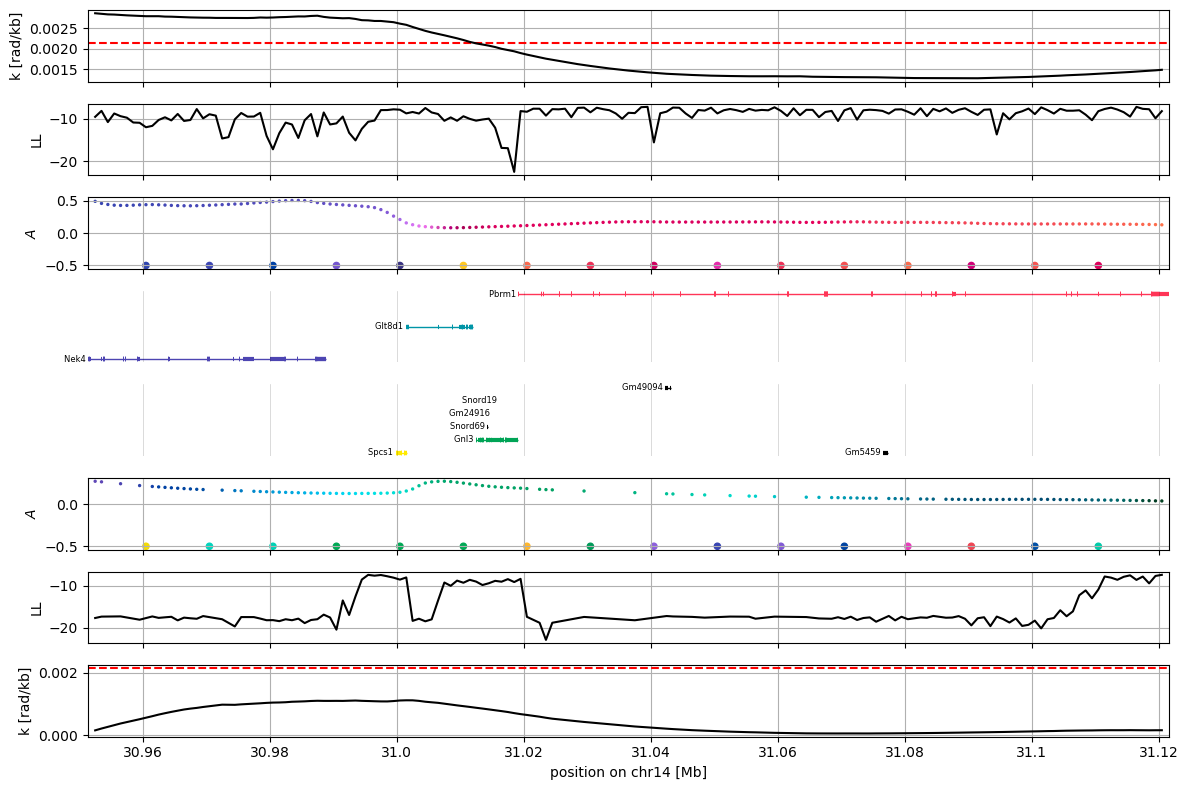

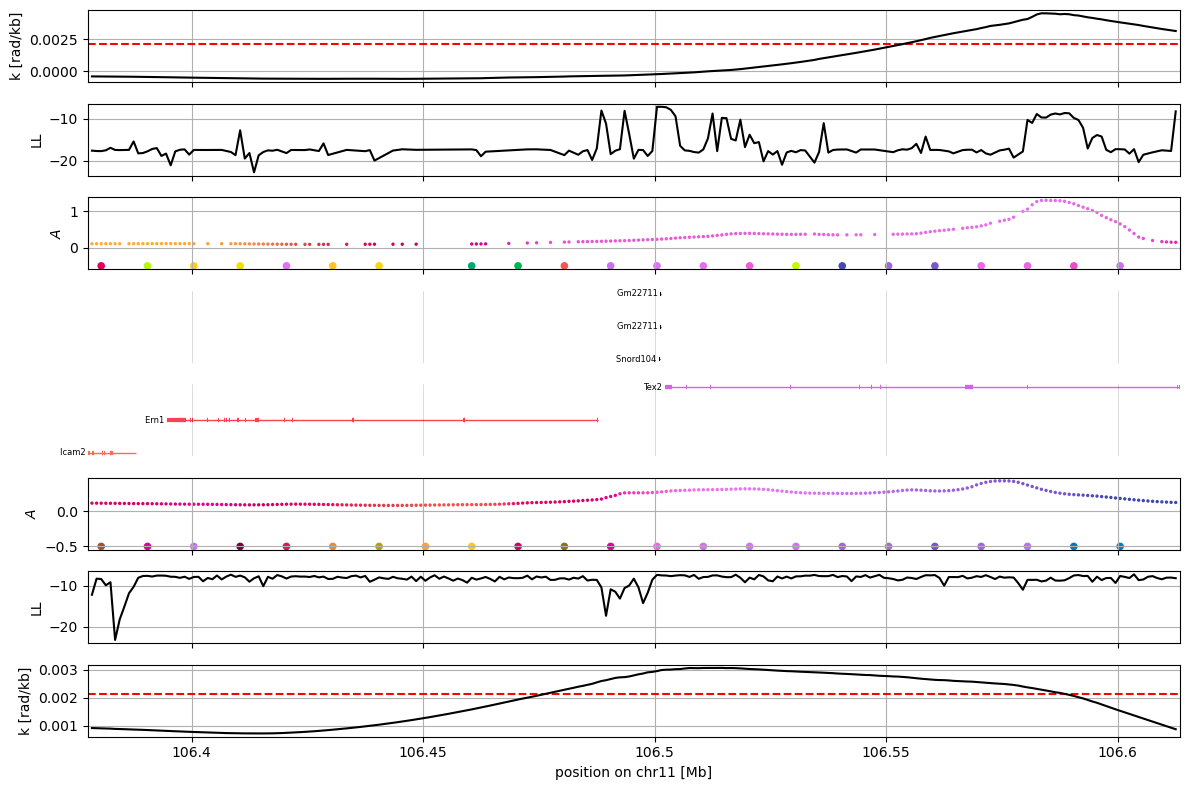

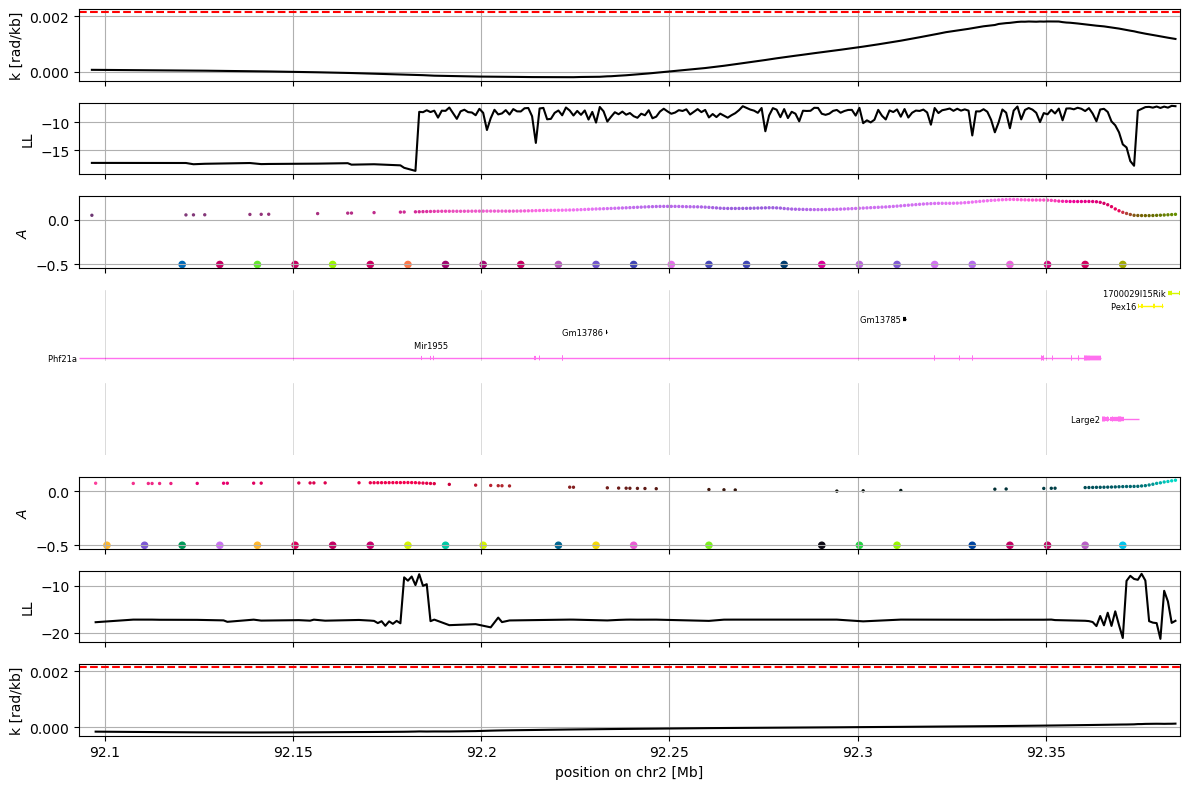

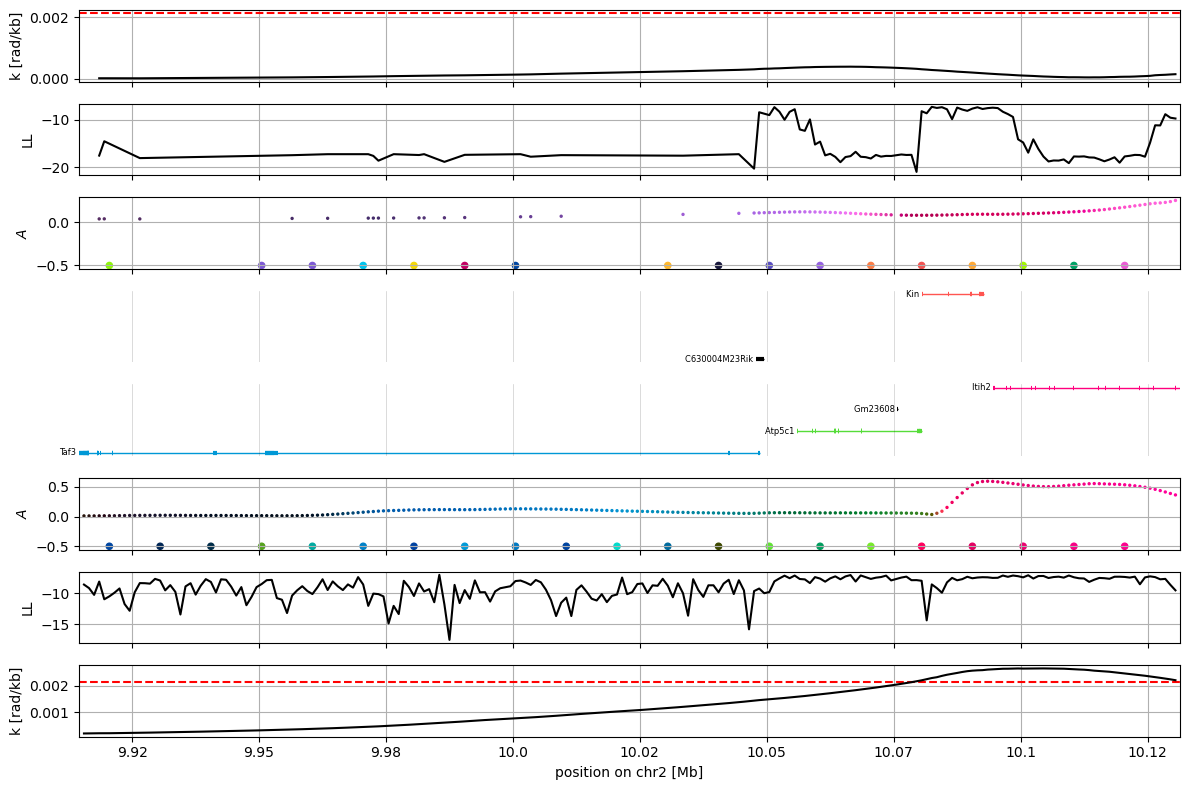

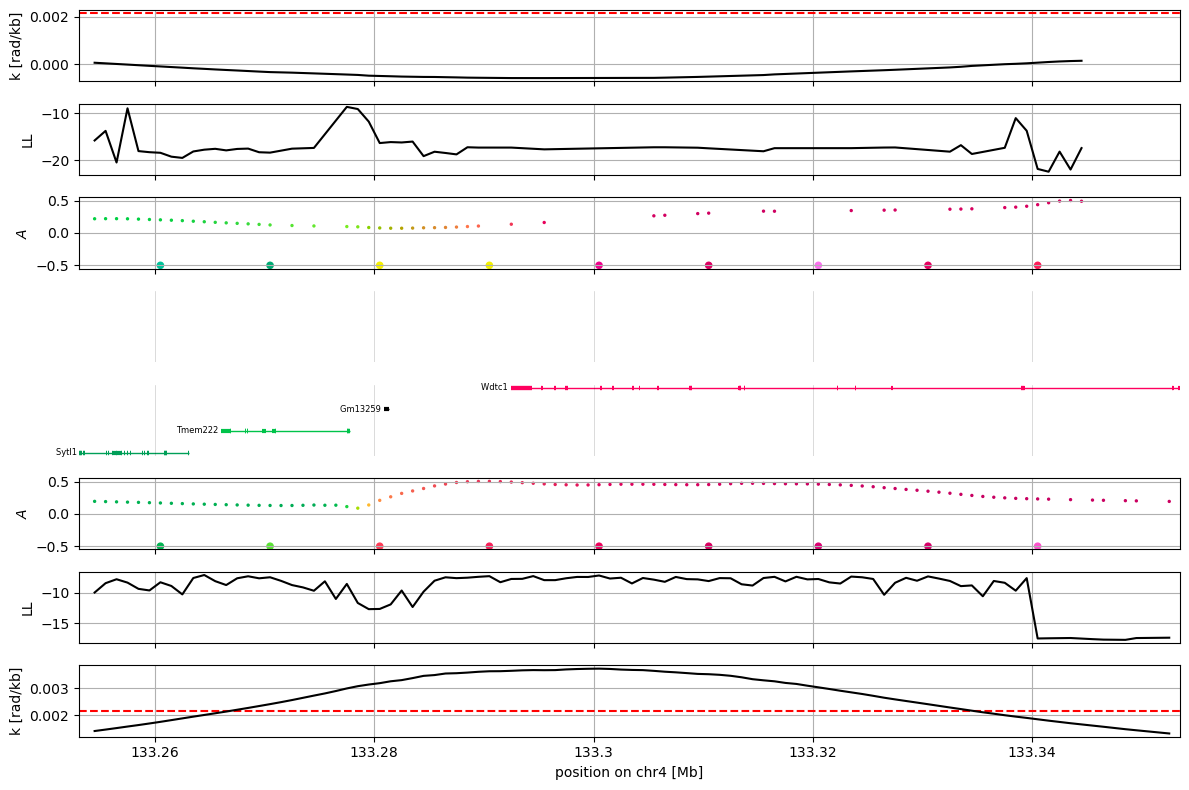

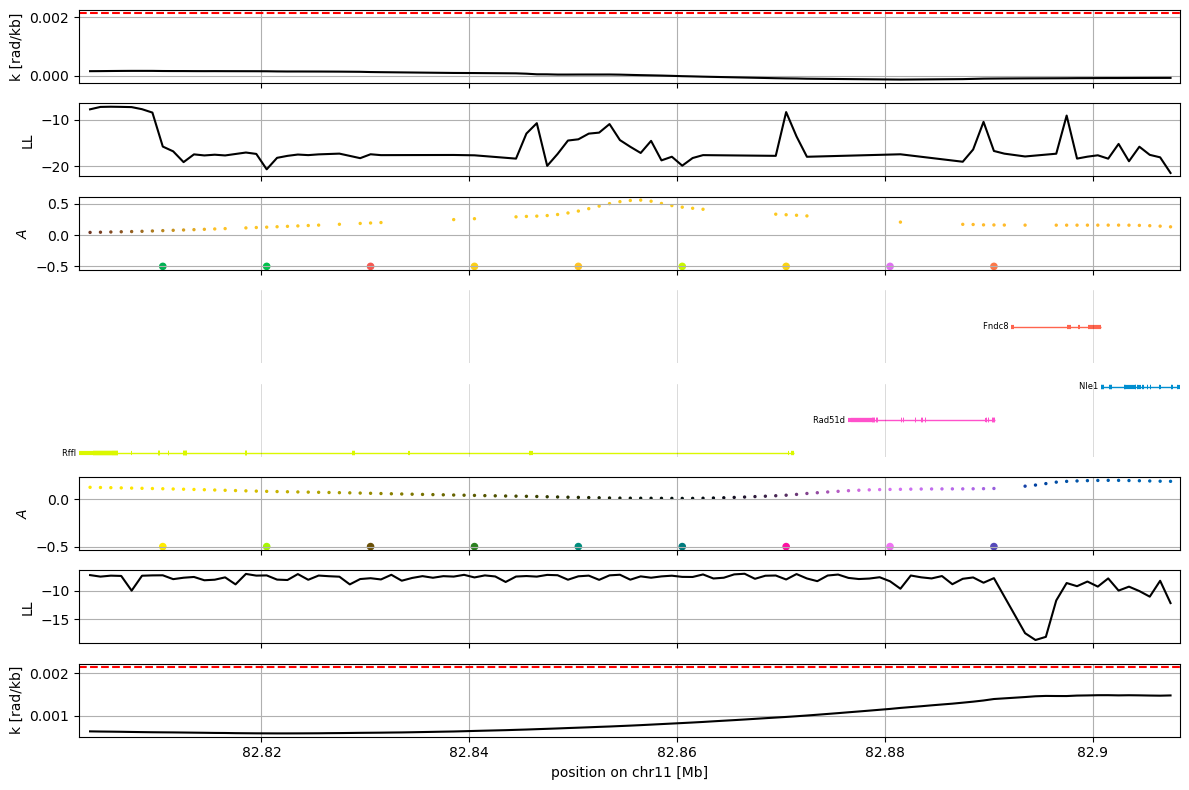

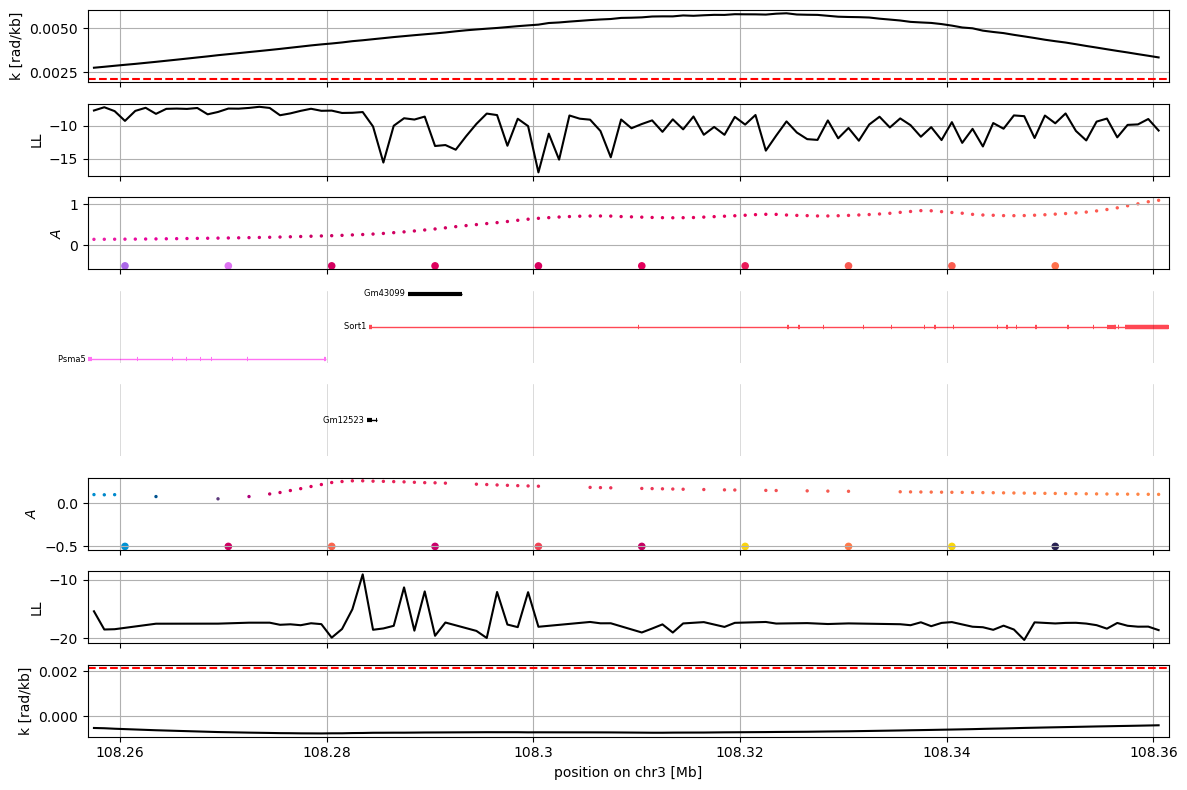

In [7]:
# plot regions with: k > 0.001 & circ_corr > 0.25 & length > 1e5 & n > 2
#gene_clusters_table[(gene_clusters_table.k_mean > 0.001) & (gene_clusters_table.circ_corr > 0.25) & (gene_clusters_table.length_bp > 100000)].sort_values('n',ascending=False)

Regions = [':'.join(r) for r in gene_clusters_table[(gene_clusters_table.k_mean > 0.001) & (gene_clusters_table.circ_corr > 0.25) & (gene_clusters_table.length_bp > 100000) & (gene_clusters_table.n > 2)].sort_values('n',ascending=False).loc[:,['chr','start','end']].astype(str).values]

print('Number of regions:',len(Regions))
#threads = 84
#with Pool(processes=threads) as pool:
#    pool.map(partial(plot_region,kalman,gene_gtf,bin_phase_amp,bin_size),Regions)

fig_folder = '../results/fig/fig5/gene_clusters'
for coord in Regions:
    plot_region(kalman,gene_gtf,bin_phase_amp,bin_size,coord,fig_folder)
   

In [21]:
gene_clusters_table.loc[(gene_clusters_table.chr == 'chr8') & (gene_clusters_table.start > 45000000) & (gene_clusters_table.end < 50000000)

,chr,start,end,strand,genes,LL_mean,k_mean,n,size,corr,circ_corr
919,chr8,45241174,45411080,-,"[F11, Klkb1, Gm45753, Cyp4v3, Fam149a, Tlr3]",0.829261,0.002579,6,169906,0.39108,0.39108


In [38]:
gene_clusters_table.loc[:,'length_bp'] = gene_clusters_table.loc[:,'size']

In [39]:
gene_clusters_table

,chr,start,end,strand,genes,LL_mean,k_mean,n,size,circ_corr,length_bp
1931,chr19,8871496,9076914,+,"[Ubxn1, Lbhd1, 1810009A15Rik, Gm49416, Ints5, ...",0.850139,-0.000919,12,NaN,0.573748,NaN
737,chr7,19530800,19750483,-,"[Ppp1r37, Gemin7, Clasrp, Relb, Clptm1, Apoc2,...",0.872803,0.001193,12,NaN,0.283244,NaN
1569,chr14,55625400,55784095,-,"[Adcy4, Ipo4, Tm9sf1, Gm49299, Mdp1, Nedd8, Ti...",0.89543,-0.000761,11,NaN,0.361931,NaN
1767,chr17,25830505,26090337,-,"[Decr2, Stub1, Rhbdl1, Gm20683, Rhot2, Mcrip2,...",0.933855,0.000047,11,NaN,0.365015,NaN
648,chr6,83054521,83200117,+,"[Aup1, Dqx1, Pcgf1, Lbx2, Ccdc142, Gm42688, Mo...",0.918476,-0.000057,10,NaN,0.275730,NaN
...,...,...,...,...,...,...,...,...,...,...,...
781,chr7,39517766,39580589,+,"[Zfp619, Gm37494]",0.760768,0.000511,2,NaN,0.221222,NaN
780,chr7,35685165,35803003,-,"[Dpy19l3, Zfp507]",0.838789,0.000445,2,NaN,0.588202,NaN
779,chr7,35334170,35438689,+,"[Rhpn2, Cep89]",0.733648,0.000417,2,NaN,0.306343,NaN
775,chr7,30956909,30989726,+,"[Gm4673, Fam187b]",0.962488,0.000598,2,NaN,-0.137439,NaN
